In [6]:
%pip install pandas
%pip install csvprint

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd
import pprint
from pathlib import Path

print(pd.__version__)

3.0.3


In [51]:
def show_face_result(vid, report_dir="."):
    vid = str(vid)
    report_dir = Path(report_dir)

    detail_path = report_dir / f"face_{vid}_detail.csv"
    result_path = report_dir / f"face_{vid}_result.csv"

    df_detail = pd.read_csv(detail_path)
    df_result = pd.read_csv(result_path)

    summary_cols = [
        "check_level",
        "check_name",
        "final_status",
        "total",
        "pass",
        "fail",
        "review",
        "skip",
        "reason",
    ]

    overall_cols = [
        "filename",
        "frames_sampled",
        "detection_gaps",
        "yaw_min",
        "yaw_max",
        "pitch_min",
        "pitch_max",
    ]


    print("=" * 50 + " Result summary " + "=" * 50)
    display(df_result[summary_cols])

    print("=" * 50 + " Frame, Yaw, Pitch " + "=" * 50)
    display(df_result.loc[df_result["check_name"].eq("OVERALL"), overall_cols])


## ตรวจสอบว่าอาสาสมัครแต่ละคนส่งไฟล์ครบ



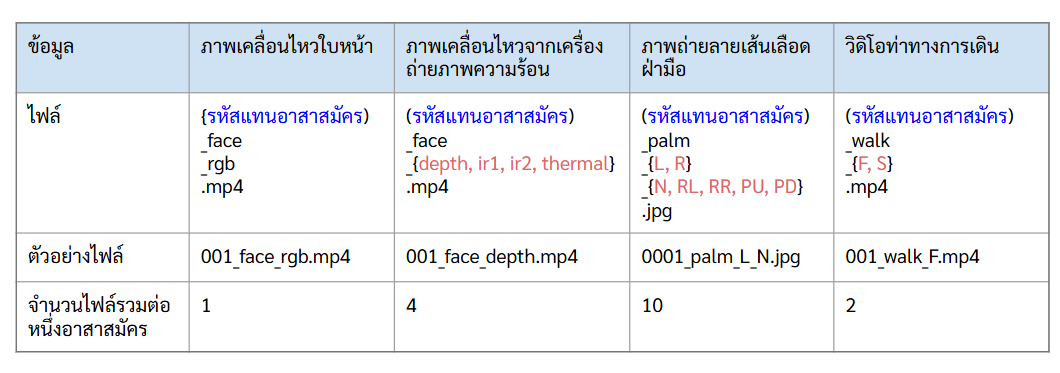

In [ ]:
from IPython.display import Image

report_dir = Path("..") 
summary_file_name_convention_path = report_dir / f"summary_file_name_convention.png"
display(Image(filename=summary_file_name_convention_path))

In [79]:
report_dir = Path(".")
filenames_path = report_dir / f"filenames.csv"
df = pd.read_csv(filenames_path)

# pd.set_option('display.max_rows', 30)
df = pd.read_csv(filenames_path)

display(df)
# pd.set_option('display.max_rows', None)

,volunteer,status,issue_type,item,path
0,1,INCOMPLETE,missing,walk_F,NaN
1,1,INCOMPLETE,missing,walk_S,NaN
2,1,INCOMPLETE,wrong_extension_case,palm_L_N,data\001_palm_L_N.JPG
3,1,INCOMPLETE,wrong_extension_case,palm_L_PD,data\001_palm_L_PD.JPG
4,1,INCOMPLETE,wrong_extension_case,palm_L_PU,data\001_palm_L_PU.JPG
...,...,...,...,...,...
139,107,INCOMPLETE,missing,palm_R_PD,NaN
140,107,INCOMPLETE,missing,walk_F,NaN
141,107,INCOMPLETE,missing,walk_S,NaN
142,106,UNRECOGNISED,unrecognised,NaN,data\106_face_rgb.mkv


In [67]:
pd.set_option('display.max_rows', None)

## ชีวมิติใบหน้า

### 0. วิดิโอตัวอย่าง

- **ไฟล์วิดิโอ**: 001_face_rgb.mp4

In [69]:
show_face_result("001")

================================================== Result summary ==================================================


,check_level,check_name,final_status,total,pass,fail,review,skip,reason
0,video,check_container,PASS,1,1,0,0,0,"container ok (.mp4, 3 channels, codec=FMP4)"
1,video,check_duration,FAIL,1,0,1,0,0,duration=25.8 < 40
2,video,check_fps,PASS,1,1,0,0,0,fps=5.00 >= 5
3,video,check_resolution,PASS,1,1,0,0,0,resolution=640x480 >= 180x180
4,video,frames_sampled,PASS,1,1,0,0,0,sampled 129 frames
5,sequence,check_turn_sequence,REVIEW,1,0,0,1,0,"structure mismatch; present=['left', 'right', ..."
6,sequence,check_turn_sequence_down,PASS,1,1,0,0,0,down: present as a segment
7,sequence,check_turn_sequence_front_hold,REVIEW,3,0,0,3,0,front held 6 frame(s) < 10 (too short)
8,sequence,check_turn_sequence_left,PASS,1,1,0,0,0,left: present as a segment
9,sequence,check_turn_sequence_right,PASS,1,1,0,0,0,right: present as a segment


================================================== Frame, Yaw, Pitch ==================================================


,filename,frames_sampled,detection_gaps,yaw_min,yaw_max,pitch_min,pitch_max
18,001_face_rgb.mp4,129.0,0.0,-56.5,54.9,-55.7,52.6


### 1. ปกติ
- คุณสมบัติตาม TOR
- **ไฟล์วิดิโอ**: 002_face_rgb.mp4

In [52]:
show_face_result("002")

================================================== Result summary ==================================================


,check_level,check_name,final_status,total,pass,fail,review,skip,reason
0,video,check_container,PASS,1,1,0,0,0,"container ok (.mp4, 3 channels, codec=h264)"
1,video,check_duration,PASS,1,1,0,0,0,duration=47.8 >= 40
2,video,check_fps,PASS,1,1,0,0,0,fps=30.00 >= 5
3,video,check_resolution,PASS,1,1,0,0,0,resolution=1920x1080 >= 180x180
4,video,frames_sampled,PASS,1,1,0,0,0,sampled 240 frames
5,sequence,check_turn_sequence,PASS,1,1,0,0,0,"structure ok; present=['left', 'right', 'down'..."
6,sequence,check_turn_sequence_down,PASS,1,1,0,0,0,down: present as a segment
7,sequence,check_turn_sequence_left,PASS,1,1,0,0,0,left: present as a segment
8,sequence,check_turn_sequence_right,PASS,1,1,0,0,0,right: present as a segment
9,sequence,check_turn_sequence_structure,PASS,1,1,0,0,0,observed: front -> left -> front -> right -> f...


================================================== Frame, Yaw, Pitch ==================================================


,filename,frames_sampled,detection_gaps,yaw_min,yaw_max,pitch_min,pitch_max
17,002_face_rgb.mp4,240.0,21.0,-71.0,69.2,-33.1,39.0


### 2. ขาดลำดับการหมุนบางส่วนไป

- ลำดับการหมุนในวิดิโอ: Front => Left => Front => Right => Front
- ลำดับการหมุนที่ถูกต้อง: Front => Left => Front => Right => Front => Up => Front => Down => Front
- **ไฟล์วิดิโอ**: 101_face_rgb.mp4

In [53]:
show_face_result("101")

================================================== Result summary ==================================================


,check_level,check_name,final_status,total,pass,fail,review,skip,reason
0,video,check_container,PASS,1,1,0,0,0,"container ok (.mp4, 3 channels, codec=h264)"
1,video,check_duration,FAIL,1,0,1,0,0,duration=27.6 < 40
2,video,check_fps,PASS,1,1,0,0,0,fps=30.00 >= 5
3,video,check_resolution,PASS,1,1,0,0,0,resolution=1080x1080 >= 180x180
4,video,frames_sampled,PASS,1,1,0,0,0,sampled 139 frames
5,sequence,check_turn_sequence,REVIEW,1,0,0,1,0,structure mismatch; present=['right']; missing...
6,sequence,check_turn_sequence_down,FAIL,1,0,1,0,0,down: not present in segments
7,sequence,check_turn_sequence_front_hold,REVIEW,3,0,0,3,0,front held 3 frame(s) < 10 (too short)
8,sequence,check_turn_sequence_left,FAIL,1,0,1,0,0,left: not present in segments
9,sequence,check_turn_sequence_left_hold,REVIEW,2,0,0,2,0,left held 6 frame(s) < 10 (too short)


================================================== Frame, Yaw, Pitch ==================================================


,filename,frames_sampled,detection_gaps,yaw_min,yaw_max,pitch_min,pitch_max
20,101_face_rgb.mp4,139.0,14.0,-72.8,69.1,6.4,26.3


### 3. ลำดับการหมุนผิด

- ลำดับการหมุนในวิดิโอ: Front => Right => Front => Left => Front => Up => Front => Down => Front
- ลำดับการหมุนที่ถูกต้อง: Front => Left => Front => Right => Front => Up => Front => Down => Front
- **ไฟล์วิดิโอ**: 102_face_rgb.mp4

In [54]:
show_face_result("102")

================================================== Result summary ==================================================


,check_level,check_name,final_status,total,pass,fail,review,skip,reason
0,video,check_container,PASS,1,1,0,0,0,"container ok (.mp4, 3 channels, codec=h264)"
1,video,check_duration,PASS,1,1,0,0,0,duration=44.1 >= 40
2,video,check_fps,PASS,1,1,0,0,0,fps=30.00 >= 5
3,video,check_resolution,PASS,1,1,0,0,0,resolution=1080x1080 >= 180x180
4,video,frames_sampled,PASS,1,1,0,0,0,sampled 222 frames
5,sequence,check_turn_sequence,REVIEW,1,0,0,1,0,"structure mismatch; present=['left', 'right', ..."
6,sequence,check_turn_sequence_down,PASS,1,1,0,0,0,down: present as a segment
7,sequence,check_turn_sequence_front_hold,REVIEW,4,0,0,4,0,front held 7 frame(s) < 10 (too short)
8,sequence,check_turn_sequence_left,PASS,1,1,0,0,0,left: present as a segment
9,sequence,check_turn_sequence_right,PASS,1,1,0,0,0,right: present as a segment


================================================== Frame, Yaw, Pitch ==================================================


,filename,frames_sampled,detection_gaps,yaw_min,yaw_max,pitch_min,pitch_max
19,102_face_rgb.mp4,222.0,16.0,-71.5,67.9,-54.0,69.6


### 4. หมุนด้วยเวลาที่สั้นไป

- หันหน้าตรงในตอนแรกด้วยเวลาน้อยกว่า 5 วินาที
- หันซ้าย ขวา บน ล่าง ด้วยเวลาน้อยกว่า 2 วินาที
- **ไฟล์วิดิโอ**: 103_face_rgb.mp4

In [55]:
show_face_result("103")

================================================== Result summary ==================================================


,check_level,check_name,final_status,total,pass,fail,review,skip,reason
0,video,check_container,PASS,1,1,0,0,0,"container ok (.mp4, 3 channels, codec=h264)"
1,video,check_duration,FAIL,1,0,1,0,0,duration=14.3 < 40
2,video,check_fps,PASS,1,1,0,0,0,fps=60.00 >= 5
3,video,check_resolution,PASS,1,1,0,0,0,resolution=1080x1080 >= 180x180
4,video,frames_sampled,PASS,1,1,0,0,0,sampled 73 frames
5,sequence,check_turn_sequence,FAIL,1,0,1,0,0,structure mismatch; present=none; missing=['le...
6,sequence,check_turn_sequence_down,FAIL,1,0,1,0,0,down: not present in segments
7,sequence,check_turn_sequence_down_hold,REVIEW,1,0,0,1,0,down held 7 frame(s) < 10 (too short)
8,sequence,check_turn_sequence_front_hold,REVIEW,4,0,0,4,0,front held 5 frame(s) < 10 (too short)
9,sequence,check_turn_sequence_left,FAIL,1,0,1,0,0,left: not present in segments


================================================== Frame, Yaw, Pitch ==================================================


,filename,frames_sampled,detection_gaps,yaw_min,yaw_max,pitch_min,pitch_max
22,103_face_rgb.mp4,73.0,9.0,-73.0,68.0,-53.6,67.1


### 5. ไม่มีลำดับการหมุน

- ลำดับการหมุนในวิดิโอ: Front
- ลำดับการหมุนที่ถูกต้อง: Front => Left => Front => Right => Front => Up => Front => Down => Front
- **ไฟล์วิดิโอ**: 104_face_rgb.mp4

In [56]:
show_face_result("104")

================================================== Result summary ==================================================


,check_level,check_name,final_status,total,pass,fail,review,skip,reason
0,video,check_container,PASS,1,1,0,0,0,"container ok (.mp4, 3 channels, codec=h264)"
1,video,check_duration,PASS,1,1,0,0,0,duration=50.3 >= 40
2,video,check_fps,PASS,1,1,0,0,0,fps=59.98 >= 5
3,video,check_resolution,PASS,1,1,0,0,0,resolution=1080x1080 >= 180x180
4,video,frames_sampled,PASS,1,1,0,0,0,sampled 252 frames
5,sequence,check_turn_sequence,FAIL,1,0,1,0,0,structure mismatch; present=none; missing=['le...
6,sequence,check_turn_sequence_down,FAIL,1,0,1,0,0,down: not present in segments
7,sequence,check_turn_sequence_left,FAIL,1,0,1,0,0,left: not present in segments
8,sequence,check_turn_sequence_right,FAIL,1,0,1,0,0,right: not present in segments
9,sequence,check_turn_sequence_structure,REVIEW,1,0,0,1,0,observed: front; matches no accepted order


================================================== Frame, Yaw, Pitch ==================================================


,filename,frames_sampled,detection_gaps,yaw_min,yaw_max,pitch_min,pitch_max
17,104_face_rgb.mp4,252.0,0.0,-3.3,5.5,-1.5,5.7


### 6. ตรวจจับใบหน้าไม่ได้

- **ไฟล์วิดิโอ**: 105_face_rgb.mp4

In [62]:
show_face_result("105")

================================================== Result summary ==================================================


,check_level,check_name,final_status,total,pass,fail,review,skip,reason
0,video,check_container,PASS,1,1,0,0,0,"container ok (.mp4, 3 channels, codec=h264)"
1,video,check_duration,PASS,1,1,0,0,0,duration=42.9 >= 40
2,video,check_fps,PASS,1,1,0,0,0,fps=60.00 >= 5
3,video,check_resolution,PASS,1,1,0,0,0,resolution=1080x1080 >= 180x180
4,video,frames_sampled,PASS,1,1,0,0,0,sampled 216 frames
5,sequence,check_turn_sequence,FAIL,1,0,1,0,0,no front-facing frame anywhere; cannot validat...
6,frame,check_face_detected,REVIEW,216,0,0,216,0,frame=0 No faces detected [judged fail-ratio=1...
7,overall,OVERALL,FAIL,7,5,1,1,0,failed checks: check_turn_sequence


================================================== Frame, Yaw, Pitch ==================================================


,filename,frames_sampled,detection_gaps,yaw_min,yaw_max,pitch_min,pitch_max
7,105_face_rgb.mp4,216.0,216.0,NaN,NaN,NaN,NaN


### 7. วิดิโอไม่ตรงตามคุณสมบัติ (1)

- ไฟล์นามสกุล .mkv
- เวลา < 40 วินาที
- resolution ทั้งวิดิโอน้อยกว่า 180 x 180 pixels
- **ไฟล์วิดิโอ**: 106_face_rgb.mkv

In [63]:
show_face_result("106")

================================================== Result summary ==================================================


,check_level,check_name,final_status,total,pass,fail,review,skip,reason
0,video,check_container,FAIL,1,0,1,0,0,extension=.mkv != .mp4
1,video,check_duration,FAIL,1,0,1,0,0,duration=6.5 < 40
2,video,check_fps,PASS,1,1,0,0,0,fps=29.97 >= 5
3,video,check_resolution,FAIL,1,0,1,0,0,resolution=160x160 < 180x180
4,video,frames_sampled,PASS,1,1,0,0,0,sampled 33 frames
5,sequence,check_turn_sequence,FAIL,1,0,1,0,0,no front-facing frame anywhere; cannot validat...
6,frame,check_face_detected,REVIEW,33,0,0,33,0,frame=0 No faces detected [judged fail-ratio=1...
7,overall,OVERALL,FAIL,7,2,4,1,0,"failed checks: check_container, check_duration..."


================================================== Frame, Yaw, Pitch ==================================================


,filename,frames_sampled,detection_gaps,yaw_min,yaw_max,pitch_min,pitch_max
7,106_face_rgb.mkv,33.0,33.0,NaN,NaN,NaN,NaN


### 8. วิดิโอไม่ตรงตามคุณสมบัติ (2)

- ไฟล์นามสกุล .jpg
- ไม่สามารถถอดเฟรมได้
- **ไฟล์**: 107_face_rgb.jpg

In [64]:
show_face_result("107")

================================================== Result summary ==================================================


,check_level,check_name,final_status,total,pass,fail,review,skip,reason
0,video,check_container,FAIL,1,0,1,0,0,extension=.jpg != .mp4
1,video,check_duration,FAIL,1,0,1,0,0,duration=0.0 < 40
2,video,check_fps,PASS,1,1,0,0,0,fps=25.00 >= 5
3,video,check_resolution,PASS,1,1,0,0,0,resolution=4032x3024 >= 180x180
4,video,frames_sampled,PASS,1,1,0,0,0,sampled 1 frames
5,sequence,check_turn_sequence,FAIL,1,0,1,0,0,no front-facing frame anywhere; cannot validat...
6,frame,check_face_detected,REVIEW,1,0,0,1,0,frame=0 No faces detected [judged fail-ratio=1...
7,overall,OVERALL,FAIL,7,3,3,1,0,"failed checks: check_container, check_duration..."


================================================== Frame, Yaw, Pitch ==================================================


,filename,frames_sampled,detection_gaps,yaw_min,yaw_max,pitch_min,pitch_max
7,107_face_rgb.jpg,1.0,1.0,NaN,NaN,NaN,NaN
